# Benchmark 3 : Rosenbrock distribution

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox import ImplicitFHMCUnbiased, ImplicitRHMCSampler, RosenbrockDualRanders, RosenbrockSoftAbs, HMCSampler, IdentityCoMetric
import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import numpy as np


In [2]:
class RosenbrockFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True, alpha: float = 1., beta : float = 1.):
        randers_cometric = RosenbrockDualRanders(alpha=alpha, beta = beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, z):
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # F* without re-eigh
        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2     # avoid the throw-away outer sqrt

        # BH terms via one Cholesky of G* (G* is already in hand)
        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)


    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # ── logdet G* and α_s via one Cholesky of G* ──────────────────────────
        L             = torch.linalg.cholesky(G_star)
        y             = torch.linalg.solve_triangular(
                            L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq          = torch.einsum("bi,bi->b", y, y)   # |ω*|²_{G*⁻¹} = 1 – α_s
        alpha_s       = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        # BCS identity: det G · det G* = α_s^{–(d+1)}
        #   ⟹ ½(d+1) log α_s + ½ log det G = –½ log det G*
        log_sigma_BH  = -0.5 * logdet_G_star

        # ── momentum scalars, without materialising G* ────────────────────────
        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)   # p^T G^{-1} p
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)          # ω* · p

        # p^T G* p = (ω*·p)² + p^T G^{-1} p / α_s   (from the MDL form of G*)
        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )



class RosenbrockRHMC(ImplicitRHMCSampler):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 alpha: float = 1.0, bounds: float = 1e3, std_0: float = 1.,
                 beta_0: float = 1., pbar: bool = False, skip_acceptance: bool = False):
        cometric = RosenbrockSoftAbs(alpha=alpha)
        super().__init__(
            cometric=cometric, l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
        )

    def U(self, z: Tensor) -> Tensor:
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20


class RosenbrockHMC(HMCSampler):
    def __init__(self, mass : float, l: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False):
        super().__init__(
            cometric=IdentityCoMetric(coscale = mass, is_diag=False),
            l=l, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
        )

    def U(self, z: Tensor) -> Tensor:
        x, y = z[:, 0], z[:, 1]
        return (100 * (y - x**2)**2 + (1 - x)**2) / 20

    def leapfrog_trajectory(self, z_0: Tensor) -> Tensor:
        v_0 = self.sample_momentum(z_0)
        traj_q, _ = self.leapfrog(z_0, v_0, return_traj=True)
        return traj_q   # (B, l+1, d)

## Step 1 : Stability of $\gamma$

In [29]:
def eval_gamma1(gamma : float, method : str, N_run : int = 100, z_0 = torch.zeros(10,2), mass : float = 1) : 
    if method == "HMC" : 
        sampler = RosenbrockHMC(
            mass = mass, 
            l = 60, #l_rhmc*N_fx
            gamma = gamma, 
            N_run = N_run
        )
    else : 
        sampler = RosenbrockRHMC(
            l = 10, 
            N_fx = 6, 
            gamma = gamma, 
            N_run = N_run
        )
    _, acc = sampler.sample(z_0, return_acceptance=True)
    return acc
    

In [30]:
grid_res = 20
mass = 20
gamma_grid = torch.linspace(0.05, 1, grid_res)
HMC_eval1 = torch.zeros(grid_res)
RHMC_eval1 = torch.zeros(grid_res)

for i in tqdm.tqdm(range(grid_res)) : 
    gamma = gamma_grid[i]
    eval_hmc = eval_gamma1(gamma, "HMC", mass = mass)
    eval_rhmc = eval_gamma1(gamma, "RHMC")
    HMC_eval1[i] = eval_hmc
    RHMC_eval1[i] = eval_rhmc


100%|██████████| 20/20 [06:48<00:00, 20.41s/it]


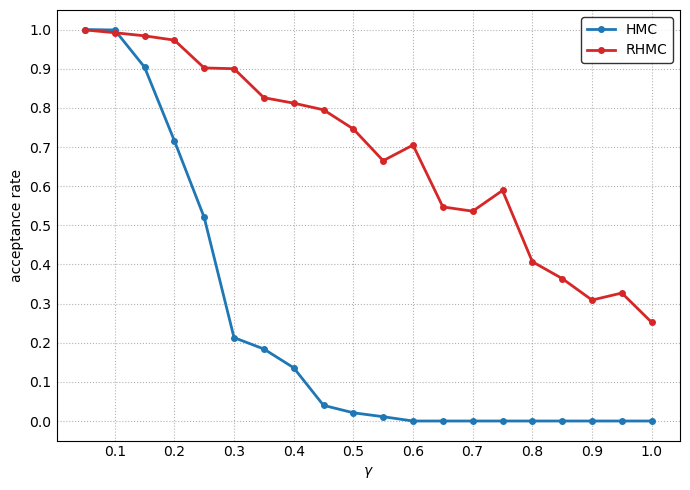

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(gamma_grid, HMC_eval1, label="HMC", color="#1f77b4", linewidth=2, marker="o", markersize=4)
ax.plot(gamma_grid, RHMC_eval1, label="RHMC", color="#d62728", linewidth=2, marker="o", markersize=4)

# # Add horizontal line at acceptance rate = 0.95
# ax.axhline(0.95, color="#d62728", linestyle="--", linewidth=1.5, alpha=0.5, label="target 0.95 acc. rate")
# # Add horizontal line at acceptance rate = 0.65
# ax.axhline(0.65, color="#1f77b4", linestyle="--", linewidth=1.5, alpha=0.5, label="target 0.65 acc. rate")

# Set graduation (ticks) every 0.1 on both x and y axes
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

ax.grid(True, linestyle=":", color="grey", alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlabel(r"$\gamma$")
ax.set_ylabel("acceptance rate")

ax.tick_params(length=0)

ax.legend(frameon=True, facecolor="white", edgecolor="black")

plt.tight_layout()
plt.show()


## Step 2 : Tunning of $l$ via grid search

In [3]:
@torch.no_grad()
def compute_energy_trajectory(sampler, z_0: torch.Tensor):
    v_0 = sampler.sample_momentum(z_0)
    traj_q, traj_p = sampler.leapfrog(z_0, v_0, return_traj=True)  # (B, l+1, d)
    n_steps = traj_q.shape[1]
    V = torch.stack([sampler.U(traj_q[:, t, :])                   for t in range(n_steps)], dim=1)
    H = torch.stack([sampler.H(traj_q[:, t, :], traj_p[:, t, :]) for t in range(n_steps)], dim=1)
    T = H - V
    return V, T, H




def plot_energy_trajectory(
    sampler_hmc, sampler_rhmc,
    gamma_hmc: float, gamma_rhmc: float,
    z_0: torch.Tensor = torch.zeros(1, 2),
):
    U_hmc,  K_hmc,  H_hmc = compute_energy_trajectory(sampler_hmc,  z_0)
    U_rhmc, K_rhmc, H_rhmc = compute_energy_trajectory(sampler_rhmc, z_0)

    for U, K, H, gamma in [
        (U_hmc,  K_hmc,  H_hmc,  gamma_hmc),
        (U_rhmc, K_rhmc, H_rhmc, gamma_rhmc),
    ]:
        fig, ax = plt.subplots(figsize=(6, 5))
        steps = torch.arange(U.shape[1]).float()
        t = gamma * steps
        ax.plot(t, U.mean(0).cpu(), color='#d62728', linewidth=1.5, label=r'$U$')
        ax.plot(t, K.mean(0).cpu(), color='#1f77b4', linewidth=1.5, label=r'$K$')
        ax.plot(t, H.mean(0).cpu(), color='black',   linewidth=1.5, label=r'$H$ (total)')
        ax.set_xlabel(r'integration time $t = \gamma \cdot n$')
        ax.set_ylabel('energy')
        ax.legend(frameon=True, loc='upper right')
        ax.grid(True, linestyle=':', color='grey', alpha=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(length=0)
        plt.tight_layout()
        plt.show()

In [4]:
gamma_hmc = 0.01
l_traj_hmc = 5000
gamma_rhmc = 0.01
l_traj_rhmc = 5000

mass = 20

sampler_hmc_traj = RosenbrockHMC(
    mass = mass, l=l_traj_hmc, gamma=gamma_hmc, N_run=1, skip_acceptance=True,
)
sampler_rhmc_traj = RosenbrockRHMC(
    l=l_traj_rhmc, N_fx=6, gamma=gamma_rhmc, N_run=1, skip_acceptance=True,
)

plot_energy_trajectory(
    sampler_hmc_traj, sampler_rhmc_traj,
    gamma_hmc=gamma_hmc, gamma_rhmc=gamma_rhmc,
    z_0=torch.zeros(1, 2),
)

KeyboardInterrupt: 

Result of this analysis : 
- For HMC : $m = 20$, $l=27$ and $\gamma = 0,46$
- For RHMC : $l = 2$ and $\gamma = 0,57$

## Step 3 : Tunning of $\beta$

In [3]:
def acf(chain, max_lag):
    """Normalized autocorrelation at lags 0..max_lag for a 1D array."""
    chain = chain - chain.mean()
    var = np.var(chain)
    return np.array([
        np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
        for k in range(max_lag + 1)
    ])

def ess_from_chain(chain, max_lag):
    """
    ESS = N / IAT,  IAT = 1 + 2 * sum_{k>=1} ACF(k).
    Sum truncated at the first negative lag (Geyer's initial positive sequence).
    """
    ac = acf(chain, max_lag)
    first_neg = np.argmax(ac[1:] < 0)
    cutoff = first_neg if first_neg > 0 else max_lag
    iat = 1.0 + 2.0 * ac[1:cutoff + 1].sum()
    return len(chain) / max(iat, 1.0)

def mean_acf(traj, dim, max_lag):
    """Average ACF over all chains for a given coordinate dimension."""
    return np.mean([acf(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])], axis=0)

def total_ess(traj, dim, max_lag):
    """Total ESS summed over all chains for a given coordinate dimension."""
    return sum(ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0]))

def mean_ess(traj, dim, max_lag):
    """Per-chain ESS averaged over chains (same metric as the beta-sweep plot)."""
    return np.mean([ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])])

def gelman_rubin(traj):
    """Split-R_hat per coordinate. traj: (n_chains, n_steps, d) tensor/array."""
    traj = traj.numpy() if hasattr(traj, "numpy") else np.asarray(traj)
    B, N, d = traj.shape
    if B < 2:
        return np.ones(d)
    chain_means = traj.mean(axis=1)
    grand_mean = chain_means.mean(axis=0)
    W = ((traj - chain_means[:, None, :]) ** 2).sum(axis=(0, 1)) / (B * (N - 1))
    B_hat = N / (B - 1) * ((chain_means - grand_mean) ** 2).sum(axis=0)
    var_hat = (N - 1) / N * W + B_hat / N
    return np.sqrt(var_hat / np.clip(W, 1e-10, None))


def central_and_band(per_chain_vec, stat: str = "mean"):
    """Central tendency across chains + STANDARD ERROR band (not raw std).

    per_chain_vec : (grid_res, batch_size)  -- one coordinate's ESS per chain.
    The uncertainty on the *mean* is std/sqrt(batch); that is what should be
    shaded to judge whether a beta-trend is real (raw std is per-chain dispersion
    and makes every beta overlap).
    """
    B = per_chain_vec.shape[1]
    central = np.median(per_chain_vec, axis=1) if stat == "median" else per_chain_vec.mean(axis=1)
    sem = per_chain_vec.std(axis=1, ddof=0) / B ** 0.5
    return central, sem


def per_chain_ess(traj, dim, max_lag):
    """Per-chain ESS for one coordinate, using the same Geyer estimator as above."""
    return np.array([ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])])


In [6]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

import tqdm

from rosenbrock_beta_worker import eval_beta_traj

l = 10
gamma = 0.57
N_run = 2000
n_traj = 100
d = 2
seed = None  

z_0_beta = torch.tensor([[0.4, 0.5]] * n_traj)
max_lag = 150
# beta=1 sits exactly on the Randers dual cometric's convexity boundary
# (alpha = 1 - beta^2 * sigmoid(||grad U||_G)^2 -> 0 wherever the gradient is
# large), so omega_star/G_star blow up there, acceptance collapses to ~0,
# chains freeze, and ESS/R_hat become numerically meaningless. Stop at 0.9.
betas = np.linspace(0.0, 0.9, 10)

# Per-chain, per-coordinate ESS for each beta: shape (len(betas), n_traj, d).
evals_full    = np.zeros((len(betas), n_traj, d))   # reduced_flip = False
evals_reduced = np.zeros((len(betas), n_traj, d))   # reduced_flip = True
acc_full,  acc_reduced  = np.zeros(len(betas)), np.zeros(len(betas))
# Per-coordinate split-R_hat across chains for each beta: shape (len(betas), d).
rhat_full    = np.zeros((len(betas), d))
rhat_reduced = np.zeros((len(betas), d))

# One worker process per (beta, flip-variant) job, capped by the number of
# cores; each worker stays single-threaded so the processes don't
# oversubscribe the CPU.
n_workers = min(os.cpu_count(), 2 * len(betas))

jobs = {}
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for i, beta in enumerate(betas):
        jobs[executor.submit(eval_beta_traj, beta, gamma, l, False, N_run, n_traj, z_0_beta, 1, seed)] = (i, "full")
        jobs[executor.submit(eval_beta_traj, beta, gamma, l, True,  N_run, n_traj, z_0_beta, 1, seed)] = (i, "reduced")

    for future in tqdm.tqdm(as_completed(jobs), total=len(jobs)):
        i, kind = jobs[future]
        traj_beta, acc, flip = future.result()
        ess_x = per_chain_ess(traj_beta, dim=0, max_lag=max_lag)
        ess_y = per_chain_ess(traj_beta, dim=1, max_lag=max_lag)
        rhat = gelman_rubin(traj_beta)
        if kind == "full":
            evals_full[i, :, 0], evals_full[i, :, 1] = ess_x, ess_y
            acc_full[i] = acc
            rhat_full[i] = rhat
        else:
            evals_reduced[i, :, 0], evals_reduced[i, :, 1] = ess_x, ess_y
            acc_reduced[i] = acc
            rhat_reduced[i] = rhat

 75%|███████▌  | 15/20 [1:50:03<29:58, 359.80s/it] /var/folders/gh/sw58v_0x4wd_8ktr762xffzh0000gn/T/ipykernel_56674/1146192349.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
/var/folders/gh/sw58v_0x4wd_8ktr762xffzh0000gn/T/ipykernel_56674/1146192349.py:6: RuntimeWarning: invalid value encountered in scalar divide
  np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
100%|██████████| 20/20 [2:06:01<00:00, 378.07s/it]


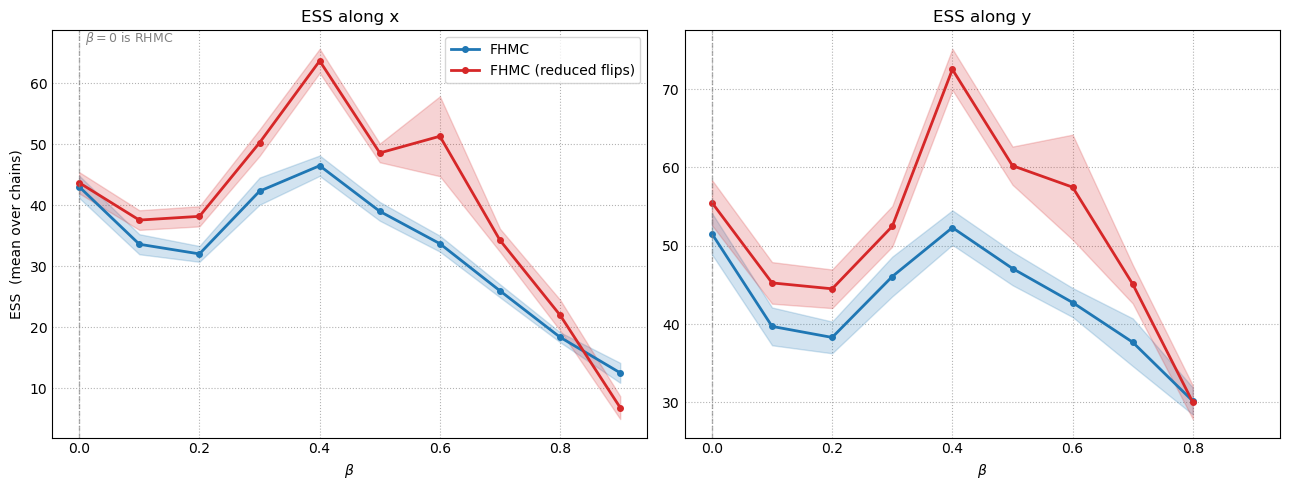

In [7]:
color_full, color_reduced = "#1f77b4", "#d62728"
coord_names = ["x", "y"]


fig, axes = plt.subplots(1, evals_full.shape[-1], figsize=(13, 5), sharex=True)

for dim, ax in enumerate(axes):
    for mat, color, label in [
        (evals_full[..., dim],    color_full,    "FHMC"),
        (evals_reduced[..., dim], color_reduced, "FHMC (reduced flips)"),
    ]:
        central, sem = central_and_band(mat, stat="mean")
        ax.plot(betas, central, label=label, color=color, linewidth=2, marker="o", markersize=4)
        ax.fill_between(betas, central - sem, central + sem, color=color, alpha=0.2)

    # beta = 0 is RHMC; shade the degenerate high-beta region.
    ax.axvline(0.0, color="grey", linestyle="--", linewidth=1, alpha=0.6)

    ax.grid(True, linestyle=":", color="grey", alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel(r"$\beta$")
    ax.set_title(f"ESS along {coord_names[dim]}")
    ax.tick_params(length=0)

axes[0].set_ylabel(r"ESS  (mean over chains)")
axes[0].text(0.01, axes[0].get_ylim()[1], r"$\beta=0$ is RHMC", va="top", fontsize=9, color="grey")
axes[0].legend(frameon=True)

plt.tight_layout()
plt.show()

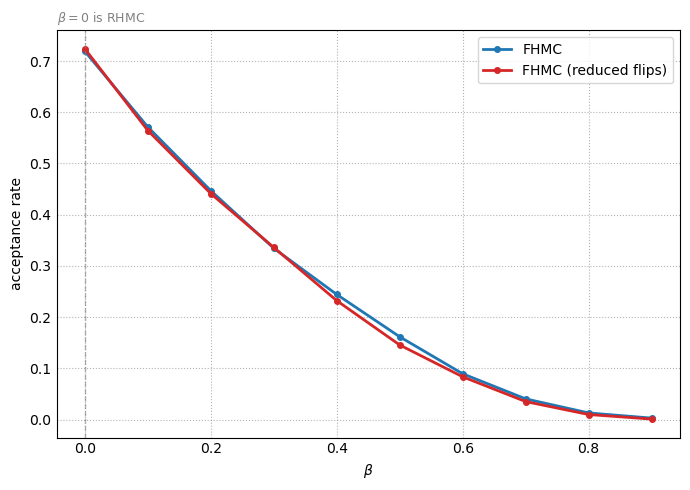

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(betas, acc_full, label="FHMC", color=color_full, linewidth=2, marker="o", markersize=4)
ax.plot(betas, acc_reduced, label="FHMC (reduced flips)", color=color_reduced, linewidth=2, marker="o", markersize=4)

# beta = 0 is RHMC.
ax.axvline(0.0, color="grey", linestyle="--", linewidth=1, alpha=0.6)

ax.grid(True, linestyle=":", color="grey", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("acceptance rate")
ax.set_title(r"$\beta=0$ is RHMC", fontsize=9, color="grey", loc="left")
ax.tick_params(length=0)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

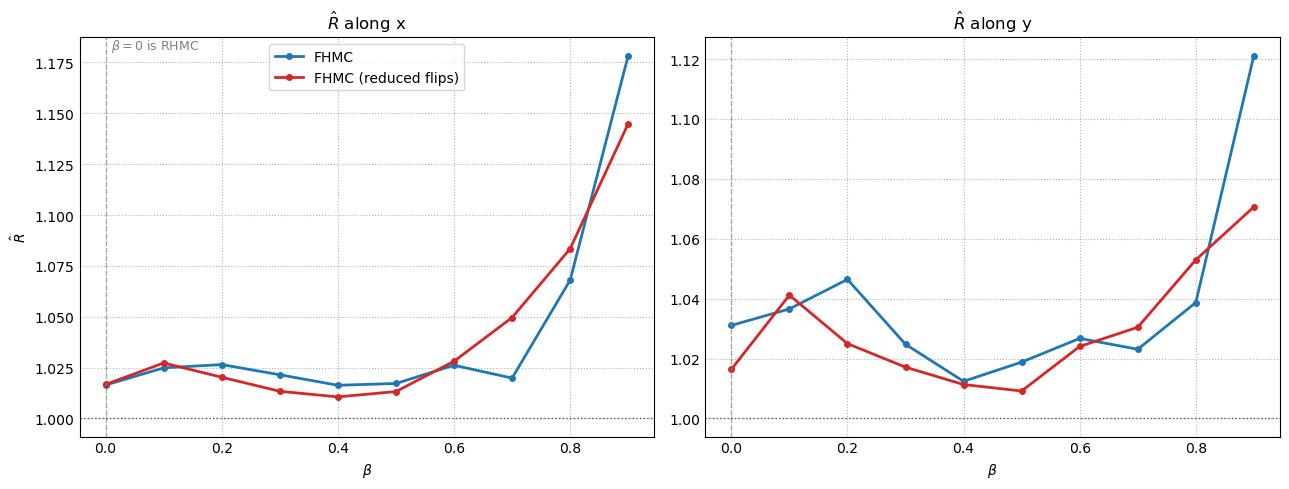

In [9]:
fig, axes = plt.subplots(1, d, figsize=(13, 5), sharex=True)

for dim, ax in enumerate(axes):
    for mat, color, label in [
        (rhat_full[:, dim],    color_full,    "FHMC"),
        (rhat_reduced[:, dim], color_reduced, "FHMC (reduced flips)"),
    ]:
        ax.plot(betas, mat, label=label, color=color, linewidth=2, marker="o", markersize=4)

    # beta = 0 is RHMC.
    ax.axvline(0.0, color="grey", linestyle="--", linewidth=1, alpha=0.6)
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1, alpha=0.6)

    ax.grid(True, linestyle=":", color="grey", alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel(r"$\beta$")
    ax.set_title(f"$\\hat R$ along {coord_names[dim]}")
    ax.tick_params(length=0)

axes[0].set_ylabel(r"$\hat R$")
axes[0].text(0.01, axes[0].get_ylim()[1], r"$\beta=0$ is RHMC", va="top", fontsize=9, color="grey")
axes[0].legend(frameon=True)

plt.tight_layout()
plt.show()